In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import scipy.stats as stats
from scipy.stats import spearmanr, pearsonr, binomtest

In [16]:
repo_root = Path('/playpen-ssd/wokwen/projects/autoeval_chatbot')
data_path = repo_root / 'ratings' / 'qwen' / 'cross_eval_ratings.csv'

df = pd.read_csv(data_path, on_bad_lines='skip')
print('Shape:', df.shape)
df.head()

Shape: (380, 10)


,Conversation_Id,Actual_ConvA,Actual_ConvB,Actual_ConvC,ConvA_Rating,ConvA_Reason,ConvB_Rating,ConvB_Reason,ConvC_Rating,ConvC_Reason
0,0,chatbot,data_no_prompt,prompt_no_data,8,Provides clear and accessible information but ...,6,Lacks alignment with the decision aid content ...,7,Addresses user concerns adequately but lacks d...
1,1,chatbot,prompt_no_data,data_no_prompt,7,The chatbot provided accurate information but ...,6,The chatbot addressed some concerns but showed...,7,The chatbot provided accurate information but ...
2,2,data_no_prompt,prompt_no_data,chatbot,8,The chatbot provided accurate information and ...,8,The chatbot provided accurate information and ...,8,The chatbot provided accurate information and ...
3,3,data_no_prompt,chatbot,prompt_no_data,4,The chatbot repeatedly avoided answering the u...,7,The chatbot provided relevant information but ...,6,The chatbot was somewhat helpful but often sug...
4,4,chatbot,prompt_no_data,data_no_prompt,9,The chatbot provided accurate information and ...,6,The chatbot repeated questions and did not int...,4,The chatbot showed signs of repetition and did...


In [17]:
def remap_chatbots(df, conv_prefixes=None):
    if conv_prefixes is None:
        conv_prefixes = ['conva','convb','convc']
    rating_cols = {}
    for p in conv_prefixes:
        # common patterns: 'conva_rating' or 'conva-rating'
        cand = next((c for c in df.columns if re.fullmatch(p + r'(_|-)?rating', c, flags=re.IGNORECASE) or c.lower().startswith(p + '_rating')), None)
        if cand is None:
            # fallback: look for column that starts with prefix and contains 'rating'
            cand = next((c for c in df.columns if c.lower().startswith(p) and 'rating' in c.lower()), None)
        rating_cols[p] = cand
    # detect actual mapping columns like 'actual_conva'
    actual_cols = {p: next((c for c in df.columns if c.lower() == f'actual_{p}'), None) for p in conv_prefixes}
    # detect reason columns per slot (e.g., 'conva_reason') or generic reason columns
    reason_cols = {p: next((c for c in df.columns if c.lower() in (f'{p}_reason', f'{p}_rating_reason')), None) for p in conv_prefixes}
    generic_reason = next((c for c in df.columns if c.lower() in ('reason','rating_reason','explanation')), None)
    
    rows = []
    for idx, row in df.iterrows():
        conv_row = {'conv_id': idx}
        for p in conv_prefixes:
            # determine bot_type (data_no_prompt, prompt_no_data, chatbot, etc.)
            bot_type = None
            if actual_cols.get(p) and pd.notna(row.get(actual_cols[p])):
                bot_type = row.get(actual_cols[p])
            elif p in df.columns and pd.notna(row.get(p)):
                bot_type = row.get(p)
            else:
                bot_type = p
            # rating value
            rating = None
            rc = rating_cols.get(p)
            if rc and rc in df.columns:
                rating = row.get(rc)
            else:
                # try '<p>_rating' fallback
                if f'{p}_rating' in df.columns:
                    rating = row.get(f'{p}_rating')
            # reason
            reason = None
            if reason_cols.get(p) and reason_cols.get(p) in df.columns:
                reason = row.get(reason_cols.get(p))
            elif generic_reason:
                reason = row.get(generic_reason)
            # Add to row with bot_type as column prefix
            conv_row[f'{bot_type}_rating'] = rating
            conv_row[f'{bot_type}_reason'] = reason
        rows.append(conv_row)
    wide = pd.DataFrame(rows)
    return wide

ratings_wide = remap_chatbots(df)
print('Wide shape:', ratings_wide.shape)
print('Columns:', ratings_wide.columns.tolist())
ratings_wide.head()

Wide shape: (380, 7)
Columns: ['conv_id', 'chatbot_rating', 'chatbot_reason', 'data_no_prompt_rating', 'data_no_prompt_reason', 'prompt_no_data_rating', 'prompt_no_data_reason']


,conv_id,chatbot_rating,chatbot_reason,data_no_prompt_rating,data_no_prompt_reason,prompt_no_data_rating,prompt_no_data_reason
0,0,8,Provides clear and accessible information but ...,6,Lacks alignment with the decision aid content ...,7,Addresses user concerns adequately but lacks d...
1,1,7,The chatbot provided accurate information but ...,7,The chatbot provided accurate information but ...,6,The chatbot addressed some concerns but showed...
2,2,8,The chatbot provided accurate information and ...,8,The chatbot provided accurate information and ...,8,The chatbot provided accurate information and ...
3,3,7,The chatbot provided relevant information but ...,4,The chatbot repeatedly avoided answering the u...,6,The chatbot was somewhat helpful but often sug...
4,4,9,The chatbot provided accurate information and ...,4,The chatbot showed signs of repetition and did...,6,The chatbot repeated questions and did not int...


In [18]:
# Cell 4: Summary stats on all ratings
rating_cols = [c for c in ratings_wide.columns if c.endswith('_rating')]
all_ratings = ratings_wide[rating_cols].values.flatten()
all_ratings = pd.Series(all_ratings).dropna().astype(float)
print('Overall stats from all bot types:')
display(all_ratings.describe(percentiles=[.1,.25,.5,.75,.9]))
skew = all_ratings.skew()
kurt = all_ratings.kurtosis()
print(f'Skewness: {skew:.3f}, Kurtosis: {kurt:.3f}')
if (all_ratings.max() <= 5 and all_ratings.min() >= 1):
    counts = all_ratings.round().value_counts().sort_index()    
    display(counts)

Overall stats from all bot types:


count    1140.000000
mean        6.935965
std         1.182372
min         4.000000
10%         5.000000
25%         6.000000
50%         7.000000
75%         8.000000
90%         8.000000
max         9.000000
dtype: float64

Skewness: -0.345, Kurtosis: -0.055


In [19]:
# Cell 5: Bot type breakdown
print('Bot type performance:')
bot_stats = {}
for col in rating_cols:
    bot_type = col.replace('_rating', '')
    ratings = ratings_wide[col].dropna().astype(float)
    bot_stats[bot_type] = {'count': len(ratings), 'mean': ratings.mean(), 'median': ratings.median(), 'std': ratings.std()}

bot_stats_df = pd.DataFrame(bot_stats).T.sort_values('mean', ascending=False)
display(bot_stats_df)

Bot type performance:


,count,mean,median,std
chatbot,380.0,7.450000,7.0,0.921811
prompt_no_data,380.0,7.073684,7.0,1.087148
data_no_prompt,380.0,6.284211,6.0,1.208267


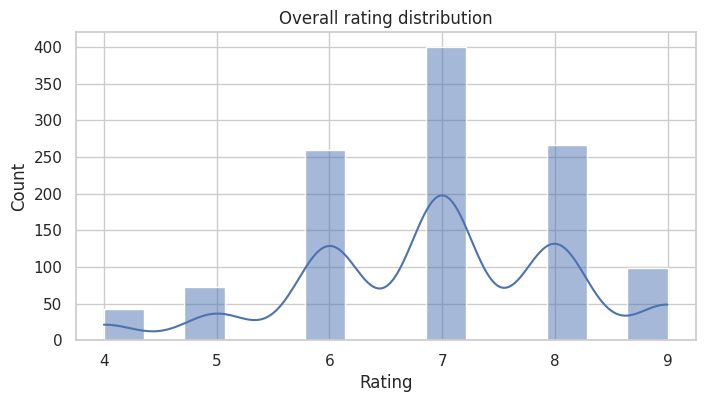

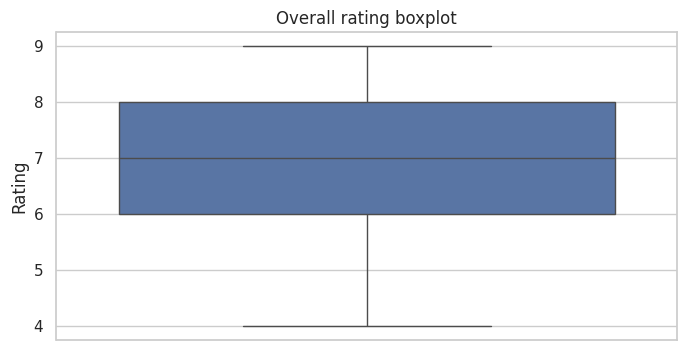

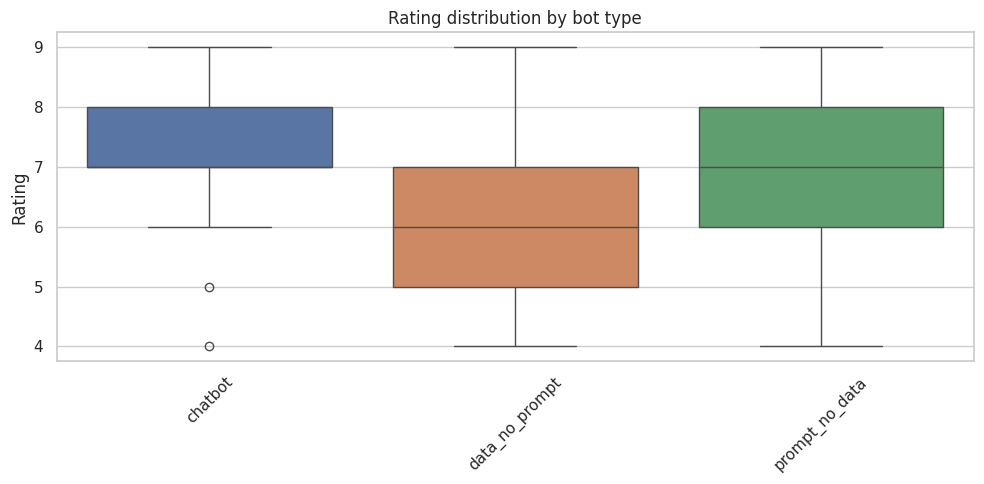

In [20]:
# Cell 6: Visualizations
sns.set(style='whitegrid')

# Overall rating distribution
plt.figure(figsize=(8,4))
sns.histplot(all_ratings, kde=True)
plt.title('Overall rating distribution')
plt.xlabel('Rating')
plt.show()

# Overall boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=all_ratings)
plt.title('Overall rating boxplot')
plt.ylabel('Rating')
plt.show()

# Per bot-type boxplot
plt.figure(figsize=(10,5))
bot_types = [col.replace('_rating', '') for col in rating_cols]
plot_data = [ratings_wide[col].dropna().astype(float).values for col in rating_cols]
sns.boxplot(data=plot_data)
plt.xticks(range(len(bot_types)), bot_types, rotation=45)
plt.ylabel('Rating')
plt.title('Rating distribution by bot type')
plt.tight_layout()
plt.show()

## Correlation & Agreement Analysis

Analyze how consistently the three bot types are rated across conversations.

In [21]:
# Prepare ratings for correlation analysis
ratings_for_corr = ratings_wide[[c for c in ratings_wide.columns if c.endswith('_rating')]].copy()
ratings_for_corr.columns = [c.replace('_rating', '') for c in ratings_for_corr.columns]

print("Pairwise Pearson Correlations:")
pearson_corr = ratings_for_corr.corr(method='pearson')
display(pearson_corr)

print("\nPairwise Spearman Rank Correlations:")
spearman_corr = ratings_for_corr.corr(method='spearman')
display(spearman_corr)

Pairwise Pearson Correlations:


,chatbot,data_no_prompt,prompt_no_data
chatbot,1.000000,0.465262,0.248543
data_no_prompt,0.465262,1.000000,0.562513
prompt_no_data,0.248543,0.562513,1.000000



Pairwise Spearman Rank Correlations:


,chatbot,data_no_prompt,prompt_no_data
chatbot,1.000000,0.454230,0.231287
data_no_prompt,0.454230,1.000000,0.572506
prompt_no_data,0.231287,0.572506,1.000000


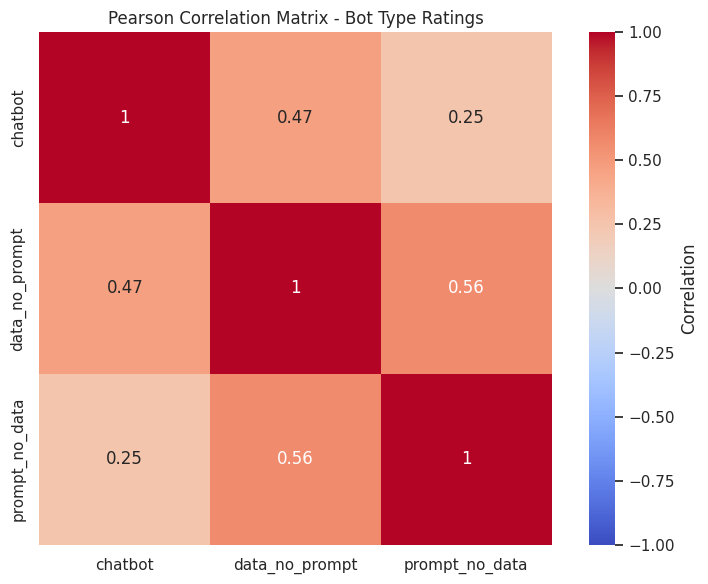


Detailed Pairwise Analysis:

chatbot vs data_no_prompt:
  Pearson:  r=0.4653, p-value=8.2762e-22
  Spearman: ρ=0.4542, p-value=9.6342e-21
  n=380 conversations

chatbot vs prompt_no_data:
  Pearson:  r=0.2485, p-value=9.2841e-07
  Spearman: ρ=0.2313, p-value=5.2216e-06
  n=380 conversations

data_no_prompt vs prompt_no_data:
  Pearson:  r=0.5625, p-value=4.3194e-33
  Spearman: ρ=0.5725, p-value=1.7972e-34
  n=380 conversations


In [22]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, square=True, 
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Pearson Correlation Matrix - Bot Type Ratings')
plt.tight_layout()
plt.show()

# Pairwise comparisons with statistical tests
print("\nDetailed Pairwise Analysis:")
print("=" * 70)

bot_types_list = [c.replace('_rating', '') for c in rating_cols]
for i, bot1 in enumerate(bot_types_list):
    for bot2 in bot_types_list[i+1:]:
        r1 = ratings_for_corr[bot1].dropna()
        r2 = ratings_for_corr[bot2].dropna()
        
        # Only compare where both have ratings
        common_idx = r1.index.intersection(r2.index)
        if len(common_idx) > 0:
            r1_common = r1[common_idx]
            r2_common = r2[common_idx]
            
            pearson_r, pearson_p = pearsonr(r1_common, r2_common)
            spearman_r, spearman_p = spearmanr(r1_common, r2_common)
            
            print(f"\n{bot1} vs {bot2}:")
            print(f"  Pearson:  r={pearson_r:.4f}, p-value={pearson_p:.4e}")
            print(f"  Spearman: ρ={spearman_r:.4f}, p-value={spearman_p:.4e}")
            print(f"  n={len(common_idx)} conversations")

## Pairwise Win Analysis

Head-to-head comparison: which bot type gets the highest rating in each conversation?

In [23]:
# Pairwise win counts
bot_types_list = [c.replace('_rating', '') for c in rating_cols]
win_matrix = pd.DataFrame(0, index=bot_types_list, columns=bot_types_list)
tie_matrix = pd.DataFrame(0, index=bot_types_list, columns=bot_types_list)

for idx, row in ratings_wide.iterrows():
    ratings_dict = {bot: row.get(f'{bot}_rating') for bot in bot_types_list}
    # Filter to only conversations where both bots have ratings
    for i, bot1 in enumerate(bot_types_list):
        for bot2 in bot_types_list[i+1:]:
            r1 = ratings_dict.get(bot1)
            r2 = ratings_dict.get(bot2)
            
            if pd.notna(r1) and pd.notna(r2):
                if r1 > r2:
                    win_matrix.loc[bot1, bot2] += 1
                elif r2 > r1:
                    win_matrix.loc[bot2, bot1] += 1
                else:
                    tie_matrix.loc[bot1, bot2] += 1
                    tie_matrix.loc[bot2, bot1] += 1

print("Win Matrix (rows beat columns):")
display(win_matrix)
print("\nTie Matrix:")
display(tie_matrix)

Win Matrix (rows beat columns):


,chatbot,data_no_prompt,prompt_no_data
chatbot,0,279,177
data_no_prompt,17,0,50
prompt_no_data,102,258,0



Tie Matrix:


,chatbot,data_no_prompt,prompt_no_data
chatbot,0,84,101
data_no_prompt,84,0,72
prompt_no_data,101,72,0


In [24]:
# Win percentages and summary
print("Win Percentage Summary:")
print("=" * 70)

for i, bot1 in enumerate(bot_types_list):
    for bot2 in bot_types_list[i+1:]:
        wins_1 = win_matrix.loc[bot1, bot2]
        wins_2 = win_matrix.loc[bot2, bot1]
        ties = tie_matrix.loc[bot1, bot2]
        total = wins_1 + wins_2 + ties
        
        if total > 0:
            pct_1 = 100 * wins_1 / total
            pct_2 = 100 * wins_2 / total
            pct_tie = 100 * ties / total
            
            print(f"\n{bot1} vs {bot2} (n={total}):")
            print(f"  {bot1}: {wins_1} wins ({pct_1:.1f}%)")
            print(f"  {bot2}: {wins_2} wins ({pct_2:.1f}%)")
            print(f"  Ties: {ties} ({pct_tie:.1f}%)")
            
            # Binomial test: is one significantly better?
            # Test if bot1 wins more than 50%
            p_value = binomtest(wins_1, wins_1 + wins_2, 0.5, alternative='two-sided').pvalue
            if p_value < 0.05:
                winner = bot1 if wins_1 > wins_2 else bot2
                print(f"  → {winner} significantly better (p={p_value:.4f})")
            else:
                print(f"  → No significant difference (p={p_value:.4f})")

Win Percentage Summary:

chatbot vs data_no_prompt (n=380):
  chatbot: 279 wins (73.4%)
  data_no_prompt: 17 wins (4.5%)
  Ties: 84 (22.1%)
  → chatbot significantly better (p=0.0000)

chatbot vs prompt_no_data (n=380):
  chatbot: 177 wins (46.6%)
  prompt_no_data: 102 wins (26.8%)
  Ties: 101 (26.6%)
  → chatbot significantly better (p=0.0000)

data_no_prompt vs prompt_no_data (n=380):
  data_no_prompt: 50 wins (13.2%)
  prompt_no_data: 258 wins (67.9%)
  Ties: 72 (18.9%)
  → prompt_no_data significantly better (p=0.0000)


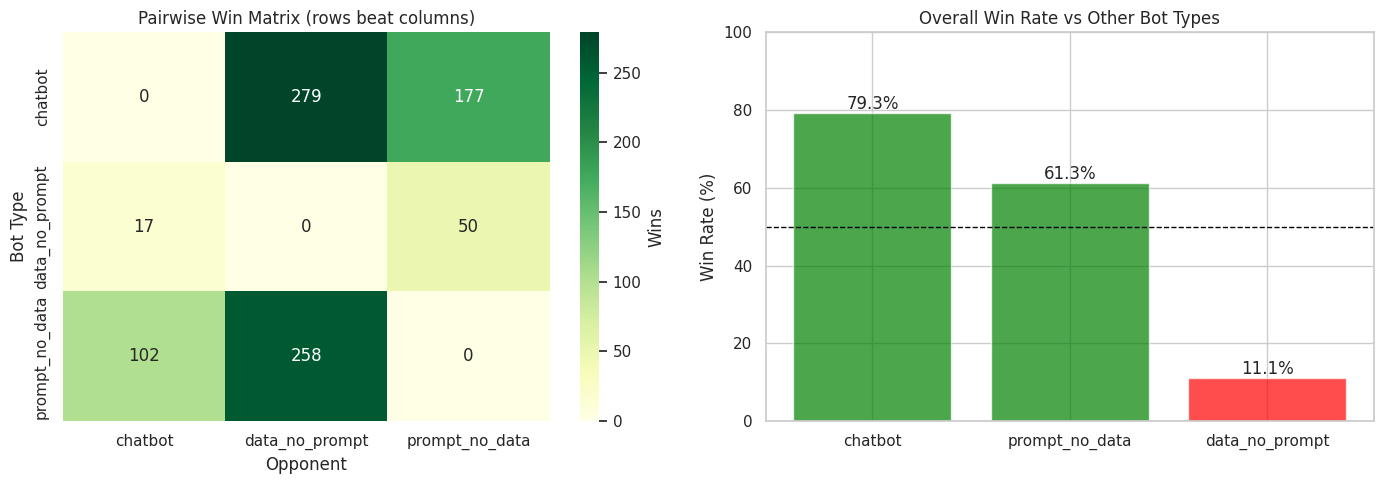

In [25]:
# Visualize win rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win count heatmap
ax = axes[0]
sns.heatmap(win_matrix, annot=True, fmt='d', cmap='YlGn', ax=ax, cbar_kws={'label': 'Wins'})
ax.set_title('Pairwise Win Matrix (rows beat columns)')
ax.set_xlabel('Opponent')
ax.set_ylabel('Bot Type')

# Compute overall win rates (percentage of wins vs losses, excluding ties)
win_rates = {}
for bot in bot_types_list:
    total_wins = win_matrix.loc[bot].sum()
    total_losses = win_matrix[bot].sum()
    total_competitions = total_wins + total_losses
    if total_competitions > 0:
        win_rate = 100 * total_wins / total_competitions
        win_rates[bot] = win_rate

ax = axes[1]
bots_sorted = sorted(bot_types_list, key=lambda x: win_rates.get(x, 0), reverse=True)
rates_sorted = [win_rates[bot] for bot in bots_sorted]
colors = ['green' if r > 50 else 'red' for r in rates_sorted]
bars = ax.bar(bots_sorted, rates_sorted, color=colors, alpha=0.7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=1, label='50% (neutral)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Overall Win Rate vs Other Bot Types')
ax.set_ylim([0, 100])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()